## Langchain 工具调用  


In [1]:
from langchain_classic.tools import tool

In [2]:
@tool
def multiply(a:int,b:int)->int:
    '''
    两数的乘积
    '''
    return a*b
  

print(multiply.name)
print(multiply.description)  
print(multiply.args)   
print(multiply.args_schema.model_json_schema())  

multiply
两数的乘积
{'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}
{'description': '两数的乘积', 'properties': {'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}, 'required': ['a', 'b'], 'title': 'multiply', 'type': 'object'}


In [3]:
## api: iu86pdg72xubuycd7odo3y8ygiubrxl

## 示例代码
import requests

url = "https://eolink.o.apispace.com/456456/weather/v001/now"

payload = {"areacode" : "101010100","lonlat" : "116.407526,39.904030"}

headers = {
    "X-APISpace-Token":"iu86pdg72xubuycd7odo3y8ygiubrxl0"
}

response=requests.request("GET", url, params=payload, headers=headers)

print(response.text)


'''
参数名	说明	参数值
areacode	城市ID，和经纬度二选一。（所有城市ID可在介绍页的相关附件中查看）	
101010100
lonlat	经纬度，用英文逗号隔开，经度在前纬度在后(格式为：经度,纬度)，会返回该经纬度最近的站点信息	
116.407526,39.904030
'''

{"status":0,"result":{"location":{"areacode":"101010100","name":"北京","country":"中国","path":"北京,北京市,北京市,中国"},"realtime":{"text":"晴","code":"00","temp":30.2,"feels_like":30,"rh":25,"wind_class":"2级","wind_speed":2.2,"wind_dir":"北风","wind_angle":17,"prec":0.0,"prec_time":"2026-06-11 14:00:00","clouds":4,"vis":30000,"pressure":1006,"dew":8,"uv":7,"weight":4,"brief":"干热","detail":"天气干热，注意补水哦"},"last_update":"2026-06-11 14:35"}}


'\n参数名\t说明\t参数值\nareacode\t城市ID，和经纬度二选一。（所有城市ID可在介绍页的相关附件中查看）\t\n101010100\nlonlat\t经纬度，用英文逗号隔开，经度在前纬度在后(格式为：经度,纬度)，会返回该经纬度最近的站点信息\t\n116.407526,39.904030\n'

In [4]:
## 天气查询封装
import requests
def get_weather(city:str) -> str:
    url = "https://eolink.o.apispace.com/456456/weather/v001/now"

    payload = {"areacode" : "101010100","lonlat" : "116.407526,39.904030"}

    headers = {
    "X-APISpace-Token":"iu86pdg72xubuycd7odo3y8ygiubrxl0"
    }

    response=requests.get(url, params=payload, headers=headers)
    return(response.text)

get_weather("北京")

'{"status":0,"result":{"location":{"areacode":"101010100","name":"北京","country":"中国","path":"北京,北京市,北京市,中国"},"realtime":{"text":"晴","code":"00","temp":30.2,"feels_like":30,"rh":25,"wind_class":"2级","wind_speed":2.2,"wind_dir":"北风","wind_angle":17,"prec":0.0,"prec_time":"2026-06-11 14:00:00","clouds":4,"vis":30000,"pressure":1006,"dew":8,"uv":7,"weight":4,"brief":"干热","detail":"又干又热，适当补充水分哦"},"last_update":"2026-06-11 14:35"}}'

In [5]:
import pandas as pd
city_df = pd.read_csv("./city.csv")
print(city_df[city_df['district'] == "朝阳"].iloc[0]['areacode/城市ID'])

101010300


In [6]:
import pandas as pd
def get_city_code(city_name:str) -> str:
    city_df = pd.read_csv("./city.csv")
    #先匹配区县
    match = city_df[city_df['district'] == city_name]
    if not match.empty:
        return match.iloc[0]['areacode/城市ID']
    
    ## 匹配城市
    match = city_df[city_df['city'] == city_name]
    if not match.empty:
        return match.iloc[0]['areacode/城市ID']
    
    ##匹配省份
    match = city_df[city_df['province'].str.contains(city_name,na=False)]    
    if not match.empty:
         return match.iloc[0]['areacode/城市ID']
    
    ##默认返回第一条的城市编码
    return city_df.iloc[0]['areacode/城市ID']

get_city_code("山东省")   

np.int64(101120101)

In [7]:
city_df = pd.read_csv("./city.csv")
# 单独执行省份筛选
res = city_df[city_df['province'].str.contains("河北省", na=False)]
print("匹配到的行数：", len(res))
# 打印前几行看看内容
print(res[['province','areacode/城市ID']].head())

匹配到的行数： 179
   province  areacode/城市ID
34      河北省      101090119
35      河北省      101090120
36      河北省      101090121
37      河北省      101090122
38      河北省      101090123


In [ ]:
import requests

@tool
def get_weather(city:str) -> str:
    '''
    获取某地的天气
    '''
    url = "https://eolink.o.apispace.com/456456/weather/v001/now"

    city_code = get_city_code(city_name=city)
    payload = {"areacode" : city_code,"lonlat" : "116.407526,39.904030"}

    headers = {
    "X-APISpace-Token":"iu86pdg72xubuycd7odo3y8ygiubrxl0"
    }

    response=requests.get(url, params=payload, headers=headers)
    data_json = response.json()
    temp = data_json['result']['realtime']['temp']
    temp = data_json.get('result').get('realtime').get('temp')
    wd = data_json.get('result').get('realtime').get('text')
    return (f"{city}今天的温度是{temp}°C 天气是{wd}")


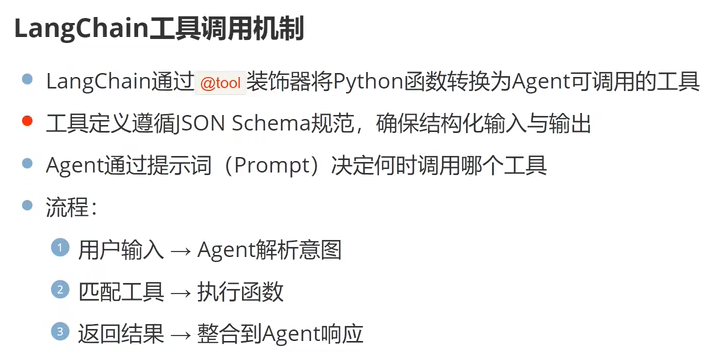  

In [34]:
from langchain_classic.agents import create_react_agent, AgentExecutor
from langchain_classic import hub
import requests
import pandas as pd
import os
import re
from langchain_community.chat_models import ChatZhipuAI
zhipuai_api_key = "4c436c37955741c290d3b97fce80fbb9.R6C2peSTtc9Stc8N"
os.environ["ZHIPUAI_API_KEY"] = zhipuai_api_key     

chat = ChatZhipuAI(
    model="glm-4",
    temperature=0.5,
)

def get_city_code(city_name:str) -> str:
    city_df = pd.read_csv("./city.csv")
    #先匹配区县
    match = city_df[city_df['district'] == city_name]
    if not match.empty:
        return match.iloc[0]['areacode/城市ID']
    
    ## 匹配城市
    match = city_df[city_df['city'] == city_name]
    if not match.empty:
        return match.iloc[0]['areacode/城市ID']
    
    ##匹配省份
    match = city_df[city_df['province'].str.contains(city_name,na=False)]    
    if not match.empty:
         return match.iloc[0]['areacode/城市ID']
    
    ##默认返回第一条的城市编码
    return city_df.iloc[0]['areacode/城市ID']


@tool
def multiply(input_str:str)->int:
    '''
    两数的乘积，
    args:
        input_str 输入的字符串，格式为a*b
    returns:int
    '''
    match = re.findall(r'\d+', input_str)
    if(len(match)==2):
        a,b = map(int,match)
    return a*b


@tool
def get_weather(city:str) -> str:
    '''
    获取某地的天气
    '''
    url = "https://eolink.o.apispace.com/456456/weather/v001/now"

    city_code = get_city_code(city_name=city)
    payload = {"areacode" : city_code,"lonlat" : "116.407526,39.904030"}

    headers = {
    "X-APISpace-Token":"iu86pdg72xubuycd7odo3y8ygiubrxl0"
    }

    response=requests.get(url, params=payload, headers=headers)
    data_json = response.json()
    temp = data_json['result']['realtime']['temp']
    temp = data_json.get('result').get('realtime').get('temp')
    wd = data_json.get('result').get('realtime').get('text')
    return (f"{city}今天的温度是{temp}°C 天气是{wd}")

## 定义工具
tools = [get_weather,multiply]

##提示词
from langchain_core.prompts import PromptTemplate

# 手动定义 ReAct prompt
prompt_template = """Answer the following questions as best you can. You have access to the following tools:

{tools}

Use the following format:

Question: the input question you must answer
Thought: you should always think about what to do
Action: the action to take, should be one of [{tool_names}]
Action Input: the input to the action
Observation: the result of the action
... (this Thought/Action/Action Input/Observation can repeat N times)
Thought: I now know the final answer
Final Answer: the final answer to the original input question

Begin!

Question: {input}
Thought:{agent_scratchpad}"""

prompt = PromptTemplate.from_template(prompt_template)
## 定义agent
agent = create_react_agent(llm=chat,tools=tools,prompt=prompt)

agent_exe = AgentExecutor(agent=agent,tools=tools,verbose=True)
agent_exe.invoke({'input': '上海今天天气如何？'})



> Entering new AgentExecutor chain...
用户想了解上海今天的天气情况。我需要使用get_weather工具来获取上海的天气信息。
Action: get_weather
Action Input: 上海
Observ上海
Observ今天的温度是30.4°C 天气是晴我通过get_weather工具获取到了上海今天的天气信息。结果显示，上海今天的温度是30.4°C，天气是晴。

Thought: I now know the final answer
Final Answer: 上海今天的温度是30.4°C，天气是晴。

> Finished chain.


{'input': '上海今天天气如何？', 'output': '上海今天的温度是30.4°C，天气是晴。'}

In [36]:
test_inputs =[
    '上海今天天气如何？',
    '2*3等于多少？',
    '帮我修车'
]

for i in test_inputs:
    resp = agent_exe.invoke({'input':i})
    print(resp)



> Entering new AgentExecutor chain...
用户想了解上海今天的天气情况。我需要使用get_weather函数来获取上海的天气信息。这个函数需要一个城市名称作为参数，用户已经明确提到了"上海"。
Action: get_weather
Action Input: 上海
Observ上海
Observ今天的温度是30.4°C 天气是晴我成功获取了上海的天气信息。根据返回的结果，上海今天的温度是30.4°C，天气状况是晴。
Thought: I now know the final answer
Final Answer: 上海今天的温度是30.4°C，天气是晴。

> Finished chain.
{'input': '上海今天天气如何？', 'output': '上海今天的温度是30.4°C，天气是晴。'}


> Entering new AgentExecutor chain...
用户想知道2乘以3等于多少。我有一个multiply工具可以计算两个数的乘积。这个工具需要一个字符串格式的输入，格式为"a*b"。我应该使用"2*3"作为输入来调用这个工具。
Action: multiply
Action Input: 2*3
Observ6我得到了multiply工具的返回结果，2*3等于6。我现在知道最终答案了。
Final Answer: 6

> Finished chain.
{'input': '2*3等于多少？', 'output': '6'}


> Entering new AgentExecutor chain...
The user is asking for help with car repair in Chinese. I need to determine if I can help with this request using the available tools.

Looking at the available tools:
1. `get_weather(city: str) -> str` - This can get weather information for a city
2. `multiply(input_str: str) -> int` - This can calc

ValueError: An output parsing error occurred. In order to pass this error back to the agent and have it try again, pass `handle_parsing_errors=True` to the AgentExecutor. This is the error: Could not parse LLM output: `I see that I don't have any tools available that can help with car repair. My available functions are only for getting weather information and performing multiplication calculations. For car repair, you would need to consult a professional mechanic, a repair manual specific to your vehicle, or online resources dedicated to automotive repair.`
For troubleshooting, visit: https://docs.langchain.com/oss/python/langchain/errors/OUTPUT_PARSING_FAILURE 